In [2]:
!pip uninstall -y torch torchvision torchaudio
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 117.7 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 41.5 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 126.9 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 59.9 MB/s  0:00:05:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 84.7 MB/s  0:00:03:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 122.8 MB/s  0:00:0100:0100:01
     ━━━━━━━━━━━

In [3]:
# from google.colab import drive
# drive.flush_and_unmount()
# print('Drive unmounted')

In [4]:
!python --version
!pip --version
!pip install --upgrade pip
# !pip list

Python 3.12.12
pip 26.1.1 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)


## Set up and Import libraries

In [5]:
!pip install openpyxl # For read excel format. TPU only
!pip install pyvi # For Vietnamese word_segment
!pip install emoji
!pip install torch
!pip install transformers

### Library

In [6]:
import pandas as pd
import os
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModel, AutoConfig, get_scheduler # AutoModelForSequenceClassification, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyvi.ViTokenizer import tokenize  # Vietnamese tokenizer
import emoji
import re
from tqdm import tqdm
import time
import numpy as np
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import pickle


In [7]:
# Check GPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# # Check for TPU
# try:
#     import torch_xla
#     import torch_xla.core.xla_model as xm
#     device = xm.xla_device()
# except ImportError:
#     # Check for GPU
#     if torch.cuda.is_available():
#         device = torch.device('cuda')
#     # Default to CPU
#     else:
#         device = torch.device('cpu')
print('Device:', device)
# EPOCHS = 6
# N_SPLITS = 10

Device: cuda:0


In [8]:
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU count: 1
GPU: Tesla P100-PCIE-16GB


## Load Data

In [9]:
# Load data

# %cd '/content/drive/MyDrive/Colab Notebooks/DS310_NLP/finegrain'
path = '/kaggle/input/datasets/trnghia1612/dataset-viso-emoj/ViGoEmotions'
with open('/kaggle/input/datasets/trnghia1612/dataset-viso-emoj/ViGoEmotions/docs/patterns.json', 'r') as f:
    pattern_dict = json.load(f)
    print(pattern_dict)
with open('/kaggle/input/datasets/trnghia1612/dataset-viso-emoj/ViGoEmotions/docs/emojis.json', 'r') as f:
    emoji_dict = json.load(f)
    print(emoji_dict)
with open('/kaggle/input/datasets/trnghia1612/dataset-viso-emoj/ViGoEmotions/docs/teencode4.txt', 'r') as f:
    content = f.read()
    lines = content.split('\n')
    teen_dict = {}
    for line in lines:
        if line.strip(): # check if not empty line
            elements = line.split('\t')
            if len(elements) >= 2:
                teen_dict.update({elements[0] : elements[1]})
    print(teen_dict)


# excel_file = pd.ExcelFile(os.path.join(path, 'corpus/dataset.xlsx'))
# excel_file = pd.ExcelFile(os.path.join(path, 'corpus/cleaned_dataset.xlsx'))
excel_file = pd.ExcelFile(os.path.join(path, 'corpus/dataset_V1.xlsx'))
# excel_file = pd.ExcelFile(os.path.join(path, 'corpus/clean_dataset_V1.xlsx'))
is_preprocessing = True # True: pre-processing text. False: No pre-processing text.

# Option 1: multiple sheets
if 'train' in excel_file.sheet_names:
    train_df = pd.read_excel(excel_file, sheet_name='train')
    val_df = pd.read_excel(excel_file, sheet_name='val')
    test_df = pd.read_excel(excel_file, sheet_name='test')

else:
# Option 2: 1 sheet
    df = pd.read_excel(excel_file, sheet_name='Sheet1')
    display(df)
    train_df = df[df['set'] == 'train']
    val_df = df[df['set'] == 'val']
    test_df = df[df['set'] == 'test']

display(train_df)
print(val_df.shape)
print(test_df.shape)

{'\\)\\)+': '))', '\\(\\(+': '((', '\\]\\]+': ']]', '\\>+': '>', '\\=+': '=', '\\:+': ':', '\\?+': '?', '\\!+': '!', 'kk+': 'haha', '\\.\\.\\.+': '...', '&gt;': '>', '&lt;': '<', '&amp;': '&', '&quot;': '"', '&apos;': "'", '&#39;': "'", '&nbsp;': ' ', '<br>': '\n'}
{':))': 'cười_lớn', '=))': 'cười_rũ_rượi', '=((': 'khóc_lớn', ':3': 'cười_mặt_mèo', ':v': 'há_mồm', '^^': 'cười_híp_mắt', ':<': 'mặt_méo', '=.=': 'bất_lực', '-_-': 'bó_tay', ':>': 'vui_vẻ', '=]]': 'nhe_răng', ':((': 'khóc_lớn', ':)': 'cười', ':-(': 'buồn', ':-@': 'sốc', ':#': 'im_lặng', '@@': 'lăn_mắt', '<(-_-)>': 'robot', ';-)': 'nháy_mắt', ':-)': 'cười', ':-<': 'buồn', ':@': 'sốc', ':X': 'im_lặng', ':-!': 'bối_rối', 'd[-_-]b': 'dj', 'O:-)': 'thiên_thần', ';d': 'nháy_mắt', ':P': 'le_lưỡi', ':-$': 'bối_rối', ':^)': 'cười', ':-D': 'cười', ":'-)": 'cười_buồn', 'O*-)': 'thiên_thần', ':-E': 'ma_cà_rồng', ':O': 'ngạc_nhiên', ':\\': 'khó_chịu', ':-&': 'bối_rối', ':-0': 'hét', ';)': 'nháy_mắt', '(:-D': 'nói_xấu', ':(': 'buồn', '$_$

,id,text,labels
0,tik000008,Xem mà ngẫm lại cuộc đời bản thân ta đã trải q...,[12]
1,5743,bức ảnh xuất sắc ❤️,"[2, 8, 3]"
2,32895,"Vừa đẹp trai, vừa tài giỏi. Nhà mặt phố, bố là...","[8, 7]"
3,you001182,"Bài học: <br>1: 5 nhìn, 4 chạm, 3 nghe, 2 ngửi...",[27]
4,12052,Dima Egiazarov bởi vì chúng tôi là người Việt ...,"[24, 23]"
...,...,...,...
16526,768,tự dưng cay mẹ mắt,[21]
16527,1983,per đã nhẫn nhịn lắm ... đến khi con sen tao c...,"[0, 10, 2]"
16528,18199,"Trời ơi, xem tin hôm qua giờ mà không biết là ...","[13, 21, 6]"
16529,tik011747,Nếu có thể quay lại tôi thề ngày hôm ấy tôi sẽ...,"[18, 4]"


(2066, 3)
(2067, 3)


In [10]:
train_df.info()
val_df.info()
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16531 entries, 0 to 16530
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      16531 non-null  object
 1   text    16531 non-null  object
 2   labels  16531 non-null  object
dtypes: object(3)
memory usage: 387.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2066 entries, 0 to 2065
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2066 non-null   object
 1   text    2066 non-null   object
 2   labels  2066 non-null   object
dtypes: object(3)
memory usage: 48.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2067 entries, 0 to 2066
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2067 non-null   object
 1   text    2067 non-null   object
 2   labels  2067 non-null   object
dtypes: object(3)
memory usage: 48.6+ KB


In [11]:
# train_df = train_df[:128]
# val_df = val_df[:64]
# test_df = test_df[:64]

### Pre-processing text

In [12]:
text = 'T thích :)))) =))))) =]]]] :>> ==== :::::: ????? !!!!!! thì t cứ :) thôi'
for pattern, replacement in pattern_dict.items():
    text = re.sub(pattern, replacement, text)
print(text)

T thích :)) =)) =]] :> = : ? ! thì t cứ :) thôi


In [13]:

def normalize_pattern(text):
    """:)))) -> :))"""
    for pattern, replacement in pattern_dict.items():
        text = re.sub(pattern=pattern, repl=replacement, string=text)

    return text


def remove_duplicate_chars(text):
    """Apply for alphabet only. Ex: cườiiiiii -> cười"""
    prev_char = None
    result = []
    for char in text:
        if char.isalpha() and prev_char == char:
            continue
        prev_char = char
        result.append(char)
    return ''.join(result)


def remove_duplicate_emoji(text):
    """😄😄😄😄 -> 😄"""
    result = []
    prev_emoji = None
    for char in text:
        if char in emoji.EMOJI_DATA:
            if char == prev_emoji:
                continue
            prev_emoji = char
        else:
            prev_emoji = None
        result.append(char)
    return ''.join(result)


def replace_teencode(text):
    """
    :param text:
    :return:
    """
    # for teen, normal in teen_dict.items():
    #     text = text.replace(teen, normal)
    # return text
    for old_word, new_word in teen_dict.items():
        pattern = re.compile(r'\b{}\b'.format(re.escape(old_word)))
        text = pattern.sub(new_word, text)
    return text


def replacing_emojis(text):
    for emoji, replacement in emoji_dict.items():
        text = text.replace(emoji, ' ' + replacement + ' ')
    return text


def clean_text(text):
    text = text.lower()
    text = normalize_pattern(text)
    text = remove_duplicate_chars(text)
    text = remove_duplicate_emoji(text)
    text = replace_teencode(text)
    # text = replacing_emojis(text)

    # remove new line char '\n'
    text = re.sub(r'(?<![.,!?;:])\n', r'. ', text)  # Replace newline with period and space if no punctuation. (1st priority)
    text = re.sub(r'\n([.,!?;:])?', r' \1', text)  # Replace newline with punctuation if present (2nd step)

    # Add spaces around punctuation marks, except in cases like 'X.Y'. This step must after new line processing.
    punctuation = r'([.,!?;:])'
    # text = re.sub(r'(?<![A-Z])' + punctuation + r'(?![A-Z])', r' \1 ', text) # except patterns like 'X.X.X'
    text = re.sub(punctuation, r' \1 ', text)  # no exceptions

    # remove extra spaces ('\s', '\n', '\t')
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print(clean_text(':)))))))'))
print(clean_text('Bao kỉ niệm lại ùa về nguyên vẹn.nhớ quá.... y.ê.u'))


: ))
bao kỉ niệm lại ùa về nguyên vẹn . nhớ quá . . . y . ê . u


In [14]:
if is_preprocessing == True:
    train_df['clean_text'] = train_df['text'].apply(clean_text)
    val_df['clean_text'] = val_df['text'].apply(clean_text)
    test_df['clean_text'] = test_df['text'].apply(clean_text)
    display(train_df)

,id,text,labels,clean_text
0,tik000008,Xem mà ngẫm lại cuộc đời bản thân ta đã trải q...,[12],xem mà ngẫm lại cuộc đời bản thân ta đã trải q...
1,5743,bức ảnh xuất sắc ❤️,"[2, 8, 3]",bức ảnh xuất sắc ❤️
2,32895,"Vừa đẹp trai, vừa tài giỏi. Nhà mặt phố, bố là...","[8, 7]","vừa đẹp trai , vừa tài giỏi . nhà mặt phố , bố..."
3,you001182,"Bài học: <br>1: 5 nhìn, 4 chạm, 3 nghe, 2 ngửi...",[27],"bài học : . 1 : 5 nhìn , 4 chạm , 3 nghe , 2 n..."
4,12052,Dima Egiazarov bởi vì chúng tôi là người Việt ...,"[24, 23]",dima egiazarov bởi vì chúng tôi là người việt ...
...,...,...,...,...
16526,768,tự dưng cay mẹ mắt,[21],tự dưng cay mẹ mắt
16527,1983,per đã nhẫn nhịn lắm ... đến khi con sen tao c...,"[0, 10, 2]",per đã nhẫn nhịn lắm . . . đến khi con sen tao...
16528,18199,"Trời ơi, xem tin hôm qua giờ mà không biết là ...","[13, 21, 6]","trời ơi , xem tin hôm qua giờ mà không biết là..."
16529,tik011747,Nếu có thể quay lại tôi thề ngày hôm ấy tôi sẽ...,"[18, 4]",nếu có thể quay lại tôi thề ngày hôm ấy tôi sẽ...


In [15]:
# Relace 'text' col by 'clean_text' col
if is_preprocessing == True:
    for df in [train_df, val_df, test_df]:
        if  'text' in df.columns and 'clean_text' in df.columns:
            df['text'] = df['clean_text']
            df.drop(columns=['clean_text'], inplace=True, errors='ignore') # ignore if 'clean_text' does not exist
    display(train_df)

,id,text,labels
0,tik000008,xem mà ngẫm lại cuộc đời bản thân ta đã trải q...,[12]
1,5743,bức ảnh xuất sắc ❤️,"[2, 8, 3]"
2,32895,"vừa đẹp trai , vừa tài giỏi . nhà mặt phố , bố...","[8, 7]"
3,you001182,"bài học : . 1 : 5 nhìn , 4 chạm , 3 nghe , 2 n...",[27]
4,12052,dima egiazarov bởi vì chúng tôi là người việt ...,"[24, 23]"
...,...,...,...
16526,768,tự dưng cay mẹ mắt,[21]
16527,1983,per đã nhẫn nhịn lắm . . . đến khi con sen tao...,"[0, 10, 2]"
16528,18199,"trời ơi , xem tin hôm qua giờ mà không biết là...","[13, 21, 6]"
16529,tik011747,nếu có thể quay lại tôi thề ngày hôm ấy tôi sẽ...,"[18, 4]"


In [16]:
# Save clean_dataset
if is_preprocessing == True:
    with pd.ExcelWriter('/kaggle/working/clean_dataset_V1.xlsx') as writer:
        train_df.to_excel(writer, sheet_name='train', index=False)
        val_df.to_excel(writer, sheet_name='val', index=False)
        test_df.to_excel(writer, sheet_name='test', index=False)
    print('Successful!')

Successful!


In [17]:
train_texts = train_df['text'].tolist()
train_labels = train_df['labels'].tolist()
print(train_texts[0])
print(train_labels[0])

xem mà ngẫm lại cuộc đời bản thân ta đã trải qua nhiều thứ ta rồi cũng sẽ lớn kí ước sẽ còn mãi trong lòng
[12]


### Encode label

In [18]:
# Load label dict
with open(os.path.join(path, 'docs/label_dict.json'), 'r') as f:
    label_dict = json.load(f)

print("Number of labels:", len(label_dict))
print(label_dict)

Number of labels: 28
{'0': 'amusement', '1': 'excitement', '2': 'joy', '3': 'love', '4': 'desire', '5': 'optimism', '6': 'caring', '7': 'pride', '8': 'admiration', '9': 'gratitude', '10': 'relief', '11': 'approval', '12': 'realization', '13': 'surprise', '14': 'curiosity', '15': 'confusion', '16': 'fear', '17': 'nervousness', '18': 'remorse', '19': 'embarrassment', '20': 'disappointment', '21': 'sadness', '22': 'grief', '23': 'disgust', '24': 'anger', '25': 'annoyance', '26': 'disapproval', '27': 'neutral'}


In [19]:
label_to_idx = {label:int(idx) for idx, label in label_dict.items()}
idx_to_label = {int(idx):label for idx, label in label_dict.items()}
print(label_to_idx)
print(idx_to_label)

{'amusement': 0, 'excitement': 1, 'joy': 2, 'love': 3, 'desire': 4, 'optimism': 5, 'caring': 6, 'pride': 7, 'admiration': 8, 'gratitude': 9, 'relief': 10, 'approval': 11, 'realization': 12, 'surprise': 13, 'curiosity': 14, 'confusion': 15, 'fear': 16, 'nervousness': 17, 'remorse': 18, 'embarrassment': 19, 'disappointment': 20, 'sadness': 21, 'grief': 22, 'disgust': 23, 'anger': 24, 'annoyance': 25, 'disapproval': 26, 'neutral': 27}
{0: 'amusement', 1: 'excitement', 2: 'joy', 3: 'love', 4: 'desire', 5: 'optimism', 6: 'caring', 7: 'pride', 8: 'admiration', 9: 'gratitude', 10: 'relief', 11: 'approval', 12: 'realization', 13: 'surprise', 14: 'curiosity', 15: 'confusion', 16: 'fear', 17: 'nervousness', 18: 'remorse', 19: 'embarrassment', 20: 'disappointment', 21: 'sadness', 22: 'grief', 23: 'disgust', 24: 'anger', 25: 'annoyance', 26: 'disapproval', 27: 'neutral'}


In [20]:

def encode_labels(label, label_dict, num_classes=28, mode=None):
    """Converts a label string to a numerical representation.

    This function takes a label string and converts it into either a one-hot encoded vector or a list of label indices,
    depending on the specified mode.

    Args:
        label (str): The label string to encode. It can be a comma-separated string of numeric labels
                     (e.g., "[13, 20, 21, 0]") or a comma-separated string of string labels
                     (e.g., '["amusement", "desire", "embarrassment"]').
        label_dict (dict): A dictionary mapping label names (strings) to their corresponding indices (integers).
        num_classes (int, optional): The total number of classes. Defaults to 28.
        mode (str, optional): The encoding mode. Can be 'label' for label indices or 'one-hot' for one-hot encoding.
                              Defaults to 'one-hot'.

    Returns:
        np.ndarray or list: The encoded label representation. If `mode` is 'one-hot', it returns a one-hot encoded vector
                            as a NumPy array. If `mode` is 'label', it returns a list of label indices.

    Examples:
        >>> encode_labels("[13, 20, 21, 0]", idx_to_label)
        array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0])
        >>> encode_labels('["amusement", "desire", "embarrassment"]', label_to_idx)
        array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
        >>> encode_labels('["amusement", "desire", "embarrassment"]', label_to_idx, mode='label')
        [0, 13, 20]
    """
    labels = label.replace('[', '').replace(']', '').replace("'", '').replace('"', '').split(',')
    labels = [label.strip() for label in labels]
    # print(labels)
    if mode is None or mode == 'one-hot':
        label_vector = np.zeros(len(label_dict), dtype=int) # default: float64
        if labels[0].isnumeric(): # If input list is numeric labels
            labels = [int(label) for label in labels]
            for idx in label_dict.values():
                if idx in labels:
                    label_vector[idx] = 1
        elif not labels[0].isnumeric(): # If input list is string labels
            for label, idx in label_dict.items():
                if label in labels:
                    label_vector[idx] = 1
        return label_vector
    elif mode == 'label':
        labels = [label_dict[label] for label in labels]
        return labels



print('Ex1:', encode_labels("[13, 20, 21, 0]", label_to_idx))
print('Ex2:', encode_labels('["amusement", "desire", "embarrassment"]', label_to_idx))
print('Ex3:', encode_labels('["amusement", "desire", "embarrassment"]', label_to_idx, mode='label'))

Ex1: [1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0]
Ex2: [1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
Ex3: [0, 4, 19]


In [21]:
# Create train-val-test with one-hot encoding for label
train_texts = train_df['text'].tolist() # 'text'
train_labels = train_df['labels'].tolist()
train_labels = [encode_labels(label, label_to_idx) for label in train_labels]
print(train_texts[0])
print(train_labels[0])

val_texts = val_df['text'].tolist()
val_labels = val_df['labels'].tolist()
val_labels = [encode_labels(label, label_to_idx) for label in val_labels]
print(val_texts[0])
print(val_labels[0])

test_texts = test_df['text'].tolist()
test_labels = test_df['labels'].tolist()
test_labels = [encode_labels(label, label_to_idx) for label in test_labels]
print(test_texts[0])
print(test_labels[0])

xem mà ngẫm lại cuộc đời bản thân ta đã trải qua nhiều thứ ta rồi cũng sẽ lớn kí ước sẽ còn mãi trong lòng
[0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
buồn nốt tý dở thôi nha🥲🤩
[1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
không coi p1 đi xem p2 thì được không ta mai huệ
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]


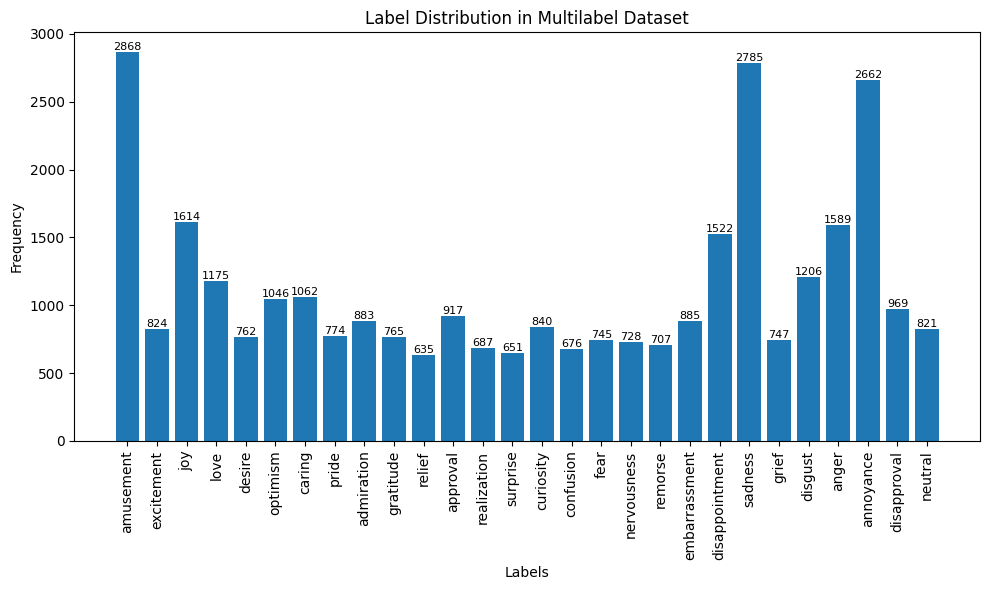

In [22]:
label_frequencies = np.sum(train_labels, axis=0) # calculate the frequency per label
label_names = list(label_dict.values())

plt.figure(figsize=(10, 6))
plt.bar(x=label_names, height=label_frequencies)
for x, y in zip(label_names, label_frequencies):
    plt.text(x, y, str(y), ha='center', va='bottom', fontsize=8)

plt.xlabel('Labels')
plt.ylabel('Frequency')
plt.title('Label Distribution in Multilabel Dataset')
plt.xticks(rotation=90) # Rotate x-axis labels for readibility
plt.tight_layout() # adjust layout to prevent labels from overlapping
plt.show()

## DataLoader

In [23]:
# Select model to deploy
model_type = 'viso' # {'viso': 'visobert', 'pho': 'phobert-base-v2}

In [24]:
if model_type == 'pho':
    print('Create tokenizer for PhoBERT')
    tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2", use_fast=False)
elif model_type == 'viso':
    print('Create tokenizer for visoBERT')
    tokenizer = AutoTokenizer.from_pretrained("uitnlp/visobert", use_fast=False)
elif model_type == 'cafe':
    print('Create tokenizer for cafeBERT')
    tokenizer = AutoTokenizer.from_pretrained('uitnlp/CafeBERT')
elif model_type == 'vi':
    print('Create tokenizer for viBERT')
    tokenizer = AutoTokenizer.from_pretrained('FPTAI/vibert-base-cased')

tokenizer

Create tokenizer for visoBERT


XLMRobertaTokenizer(name_or_path='uitnlp/visobert', vocab_size=15002, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	15001: AddedToken("<mask>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

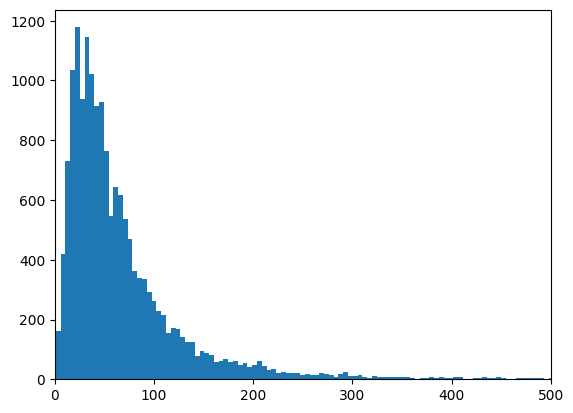

In [25]:
# vẽ biểu đồ thể hiện phân bố chiều dài của câu trong tập dữ liệu.
import matplotlib.pyplot as plt

plt.hist([len(s) for s in train_texts], bins=192)
plt.xlim(0, 500)
plt.show()

In [26]:
max_len = 200 # max_len should cover at least 95% texts
print(len([t for t in train_texts if len(t) <= max_len]) / len(train_texts))

0.9548726634807332


In [27]:
# Encode dữ liệu
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = torch.tensor(labels, dtype=torch.float)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = self.texts[idx]
        text = tokenize(text)

        encoding = self.tokenizer(
            text,
            truncation=True,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'text': text,
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'targets': self.labels[idx],
        }

# Tạo dataset
train_dataset = SentimentDataset(train_texts, train_labels, tokenizer, max_len=max_len)
val_dataset = SentimentDataset(val_texts, val_labels, tokenizer, max_len=max_len)
test_dataset = SentimentDataset(test_texts, test_labels, tokenizer, max_len=max_len)

with open(f'corpus/dataset_{model_type}bert.pkl', 'wb') as f:
    pickle.dump((train_dataset, val_dataset, test_dataset), f)

/tmp/ipykernel_141/4119543225.py:5: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  self.labels = torch.tensor(labels, dtype=torch.float)


FileNotFoundError: [Errno 2] No such file or directory: 'corpus/dataset_visobert.pkl'

In [28]:
train_dataset[5]

{'text': 'giờ mới biết',
 'input_ids': tensor([  0, 321,   9,  54,  14, 152,   2,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1, 

In [29]:
for i in range(0, 10):
    print(train_dataset[i]['text'])

xem mà ngẫm lại cuộc_đời bản_thân ta đã trải qua nhiều thứ ta rồi cũng sẽ lớn kí ước sẽ còn mãi trong lòng
bức ảnh xuất_sắc ❤ ️
vừa đẹp_trai , vừa tài_giỏi . nhà mặt_phố , bố làm to
bài_học : . 1 : 5 nhìn , 4 chạm , 3 nghe , 2 ngửi , 1 nếm . 2 : tư_duy 3 % . 3 : phương_pháp thở
dima egiazarov bởi_vì chúng_tôi là người việt_nam , còn hiểu hay không thì kệ mẹ bạn
giờ mới biết
cảmày thấy tự_hào về đấtao nướchị mình
nhìn mặt là cười phọt rồi
cris minh algeria nó theo đạo hồi . không được chuyển giới . nhiều người là nữ nhưng vẫn tiết nhiều tetosteron hơn bình_thường . cơ_bắp sẽ phát_triển mạnh hơn
nó giống tao ghê . gặp tao tao cũng chọn mày


In [30]:
# Iterate through the dataset to view the mappings for a specific sample
for idx in range(1):  # Adjust range to view more samples
    sample = train_dataset[idx]  # Get one sample
    input_ids = sample['input_ids']  # Extract input_ids
    tokens = tokenizer.convert_ids_to_tokens(input_ids.tolist())  # Convert IDs to tokens

    print(f"Original Text: {sample['text']}")
    print(f"Input IDs: {input_ids.tolist()}")
    print(f"Tokens: {tokens}")
    print(f"Labels: {sample['targets'].tolist()}")
    print("\nIndex-Token Mapping:")
    for i, token in enumerate(tokens):
        print(f"Index {i}: \tToken {token}")


Original Text: xem mà ngẫm lại cuộc_đời bản_thân ta đã trải qua nhiều thứ ta rồi cũng sẽ lớn kí ước sẽ còn mãi trong lòng
Input IDs: [0, 34, 157, 50, 23, 3643, 10, 63, 286, 468, 14800, 14648, 52, 14, 169, 14800, 785, 91, 309, 197, 26, 99, 297, 18, 167, 594, 309, 24, 80, 5, 93, 237, 816, 1496, 1700, 237, 5, 119, 9, 405, 26, 68, 10, 295, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Tokens: ['<s>', '▁x', 'em', '▁mà', '▁ng', 'ẫm', '▁l', 'ại', '▁cu', 'ộc', '_', 'đ', 'ời', '▁b', 'ản', '_', 'th', 'ân', '▁ta', '▁đã', '▁tr', 'ải', '▁qua', '▁nh', 'iều', '▁thứ', '▁ta', '▁r', 'ồi', 

In [31]:
# DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2) # num_workers=2: Sử dụng 2 tiến trình để tải dữ liệu song song -> cải thiện tốc độ nạp dữ liệu
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)
train_loader.__init__

<bound method DataLoader.__init__ of <torch.utils.data.dataloader.DataLoader object at 0x7931dad34320>>

## Model

In [32]:

# Load tokenizer và model
class ModelSentimentClassifier(nn.Module):
    def __init__(self, n_classes, model_type='pho'):
        super(ModelSentimentClassifier, self).__init__()
        # Select BERT model
        if model_type == 'pho':
            bert_model = 'vinai/phobert-base-v2'
        elif model_type == 'viso':
            bert_model = 'uitnlp/visobert'
        elif model_type == 'cafe':
            bert_model = 'uitnlp/CafeBERT'
        elif model_type == 'vi':
            bert_model = 'FPTAI/vibert-base-cased'

        # Load config with custom dropout settings
        config = AutoConfig.from_pretrained(
            bert_model,
            hidden_dropout_prob=0.1,
            attention_probs_dropout_prob=0.1
        )

        # Download BERT
        self.bert = AutoModel.from_pretrained(bert_model, config=config)
        self.drop = nn.Dropout(p=0.2)
        self.fc = nn.Linear(self.bert.config.hidden_size, n_classes)

    def forward(self, input_ids, attention_mask):
        last_hidden_state, output = self.bert(
            input_ids = input_ids,
            attention_mask = attention_mask,
            return_dict = False # Dropout sẽ báo lỗi nếu không có điều này
        )

        x = self.drop(output)
        x = self.fc(x)
        return {'logits': x} # add more if needed

model = ModelSentimentClassifier(n_classes=len(label_dict), model_type=model_type).to(device)
model

# model_bert = "uitnlp/visobert"
# tokenizer = AutoTokenizer.from_pretrained(model_bert, use_fast=False) # https://huggingface.co/uitnlp/visobert
# model = AutoModelForSequenceClassification.from_pretrained(model_bert, num_labels=28) # AutoModelForSequenceClassification, model Bert thêm 2 layers Dense và Dropout với droprate = 0.1.
# model.to(device) # Move model to GPU if GPU is available

pytorch_model.bin:   0%|          | 0.00/390M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: uitnlp/visobert
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ModelSentimentClassifier(
  (bert): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(15004, 768, padding_idx=1)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): XLMRobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
   

model.safetensors:   0%|          | 0.00/390M [00:00<?, ?B/s]

In [33]:
# Hàm để tính toán số lượng tham số và phân loại chúng
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable_params = total_params - trainable_params

    # In ra các lớp và tham số trainable/non-trainable
    print(f"\n--- Trainable vs Non-trainable Parameters ---")
    for name, param in model.named_parameters():
        if param.requires_grad:
            print(f"Trainable: {name} ({param.numel()} parameters)")
        else:
            print(f"Non-trainable: {name} ({param.numel()} parameters)")

    return total_params, trainable_params, non_trainable_params

# Tính toán và hiển thị kết quả
total_params, trainable_params, non_trainable_params = count_parameters(model)
print(f"\nTotal params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"Non-trainable params: {non_trainable_params:,}")


--- Trainable vs Non-trainable Parameters ---
Trainable: bert.embeddings.word_embeddings.weight (11523072 parameters)
Trainable: bert.embeddings.token_type_embeddings.weight (1536 parameters)
Trainable: bert.embeddings.LayerNorm.weight (768 parameters)
Trainable: bert.embeddings.LayerNorm.bias (768 parameters)
Trainable: bert.embeddings.position_embeddings.weight (394752 parameters)
Trainable: bert.encoder.layer.0.attention.self.query.weight (589824 parameters)
Trainable: bert.encoder.layer.0.attention.self.query.bias (768 parameters)
Trainable: bert.encoder.layer.0.attention.self.key.weight (589824 parameters)
Trainable: bert.encoder.layer.0.attention.self.key.bias (768 parameters)
Trainable: bert.encoder.layer.0.attention.self.value.weight (589824 parameters)
Trainable: bert.encoder.layer.0.attention.self.value.bias (768 parameters)
Trainable: bert.encoder.layer.0.attention.output.dense.weight (589824 parameters)
Trainable: bert.encoder.layer.0.attention.output.dense.bias (768 param

In [34]:
EPOCHS = 12
optimizer = AdamW(model.parameters(), lr=5e-5)

# Learning rate will gradually increase for the 1st epochs (warmup phase) and then linearly decrease until the end of training to be almost zero.
lr_scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=len(train_loader), num_training_steps=len(train_loader)*EPOCHS)

## Train and Test

In [35]:

# Loss function: BCEWithLogitsLoss (Binary Cross Entropy with Logits) cho bài toán multilabel, dự đoán độc lập mỗi nhóm
label_counts = np.sum(train_labels, axis=0)
total_samples = len(train_labels)
pos_weight = torch.tensor([(total_samples - count) / count for count in label_counts]).to(device)
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight) # multilabel classification, pos_weight: balance label weight

In [36]:
def train(model, data_loader, loss_fn, optimizer, device='cpu', threshold=0.5):
    model.train()
    losses = []
    all_targets = []
    all_preds = []

    for data in data_loader:
        input_ids = data['input_ids'].to(device)
        attention_mask = data['attention_mask'].to(device)
        targets = data['targets'].to(device)

        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        logits = outputs['logits']

        # Compute loss
        loss = loss_fn(logits, targets)
        losses.append(loss.item())

        # Backpropagation
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # prevent exploding gradients
        optimizer.step()
        lr_scheduler.step()

        # Predictions
        preds = torch.sigmoid(logits)
        preds = (preds >= threshold).int()

        # Append result
        all_targets.append(targets.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    # Merge all batch
    all_targets = np.vstack(all_targets)
    all_preds = np.vstack(all_preds)

    # Calculate mean loss
    mean_loss = np.mean(losses)

    # Calculate accuracy
    correct_per_label = (all_targets == all_preds).sum(axis=0)  # Số lượng đúng cho từng nhãn
    total_per_label = all_targets.shape[0]  # Tổng số mẫu
    label_accuracies = correct_per_label / total_per_label  # Accuracy từng nhãn
    average_accuracy = label_accuracies.mean()  # Trung bình accuracy của tất cả nhãn

    # Calculate F1-score
    macro_f1 = f1_score(all_targets, all_preds, average='macro')

    print(f'Train Loss: {mean_loss:.4f} | Average Accuracy: {average_accuracy:.4f} | Macro F1: {macro_f1:.4f}')
    return mean_loss, average_accuracy, macro_f1

In [37]:
def eval(model, data_loader, loss_fn, device='cpu', threshold=0.5):
    model.eval()
    losses = []
    all_targets = []
    all_preds = []

    with torch.no_grad():
        for data in data_loader:
            input_ids = data['input_ids'].to(device)
            attention_mask = data['attention_mask'].to(device)
            targets = data['targets'].to(device) # Shape: (batch_size, num_classes)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            logits = outputs['logits'] # Shape: (batch_size, num_classes)

            # Compute loss
            loss = loss_fn(logits, targets)
            losses.append(loss.item())

            # Predictions
            preds = torch.sigmoid(logits)
            preds = (preds >= threshold).int()

            # Append results
            all_targets.append(targets.cpu().numpy())
            all_preds.append(preds.cpu().numpy())

    # Merge all batches
    all_targets = np.vstack(all_targets)
    all_preds = np.vstack(all_preds)

    # Calculate mean loss
    mean_loss = np.mean(losses)

    # Calculate accuracy per label
    correct_per_label = (all_targets == all_preds).sum(axis=0)
    total_per_label = all_targets.shape[0]
    label_accuracies = correct_per_label / total_per_label
    average_accuracy = label_accuracies.mean()

    # Calculaate macro F1-score
    macro_f1 = f1_score(all_targets, all_preds, average='macro')

    # Print results
    print(f'Validation Loss: {mean_loss:.4f} | Average Accuracy: {average_accuracy:.4f} | Macro F1: {macro_f1:.4f}')

    return mean_loss, average_accuracy, macro_f1

In [38]:
def test(model, data_loader, device='cpu', threshold=0.5):
    model.to(device)
    model.eval()
    texts, predict_probs, predicts, real_values = [], [], [], []

    with torch.no_grad():
        for data in data_loader:
            text = data['text']
            input_ids = data['input_ids'].to(device)
            attention_mask = data['attention_mask'].to(device)
            targets = data['targets'].to(device) # Shape: (batch_size, num_classes)


            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            logits = outputs['logits'] # Shape: (batch_size, num_classes)

            # Predictions
            probs = torch.sigmoid(logits) # Convert logits to probabilities
            preds = (probs >= threshold).int()  # Apply threshold to get binary predictions

            # Append results
            texts.extend(text)
            predicts.extend(preds.cpu().numpy())
            predict_probs.extend(probs.cpu().numpy())
            real_values.extend(targets.cpu().numpy())


        # Convert lists to tensors/numpy arrays
        predicts = torch.tensor(predicts)
        predict_probs = torch.tensor(predict_probs)
        real_values = torch.tensor(real_values)

        # # Generate classification report (macro, micro, and per-label)
        # print("Classification Report:")
        # print(classification_report(real_values, predicts, target_names=list(label_dict.values()), zero_division=0))

        # # Save to excel
        # report = classification_report(real_values, predicts, target_names=list(label_dict.values()), zero_division=0, output_dict=True)
        # print(report)
        # report_df = pd.DataFrame(report).transpose()
        # report_df.to_excel(f'classification_report_{model_type}_bert.xlsx', index=True)

        return predict_probs, predicts, real_values

In [39]:

all_train_losses = []
all_train_accuracies = []
all_train_f1 = []
all_val_losses = []
all_val_accuracies = []
all_val_f1 = []
best_f1 = 0

# Training loop
start_time = time.time()
for epoch in tqdm(range(EPOCHS), desc='Epoch'):
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{EPOCHS}, Learning Rate: {current_lr}")
    train_loss, train_acc, train_f1 = train(model, train_loader, loss_fn, optimizer, device)
    all_train_losses.append(train_loss)
    all_train_accuracies.append(train_acc)
    all_train_f1.append(train_f1)

    val_loss, val_acc, val_f1 = eval(model, val_loader, loss_fn, device)
    all_val_losses.append(val_loss)
    all_val_accuracies.append(val_acc)
    all_val_f1.append(val_f1)

    if val_f1 > best_f1:
        print('Saving the model....')
        torch.save(model, f'/kaggle/working/{model_type}bert.pth')
        best_f1 = val_f1

    time.sleep(1)

print(f'Completed! {(time.time() - start_time):.2f} seconds')

Epoch:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 1/12, Learning Rate: 0.0
Train Loss: 1.0644 | Average Accuracy: 0.6720 | Macro F1: 0.2202
Validation Loss: 0.8423 | Average Accuracy: 0.8076 | Macro F1: 0.3543
Saving the model....


Epoch:   8%|▊         | 1/12 [05:25<59:38, 325.28s/it]

Epoch 2/12, Learning Rate: 5e-05
Train Loss: 0.7329 | Average Accuracy: 0.8283 | Macro F1: 0.3878
Validation Loss: 0.7285 | Average Accuracy: 0.8525 | Macro F1: 0.4240
Saving the model....


Epoch:  17%|█▋        | 2/12 [10:50<54:14, 325.44s/it]

...

Epoch 11/12, Learning Rate: 9.090909090909091e-06
Train Loss: 0.0697 | Average Accuracy: 0.9892 | Macro F1: 0.9361
Validation Loss: 1.3831 | Average Accuracy: 0.9362 | Macro F1: 0.5578
Saving the model....


Epoch:  92%|█████████▏| 11/12 [59:53<05:27, 327.21s/it]

Epoch 12/12, Learning Rate: 4.5454545454545455e-06
Train Loss: 0.0591 | Average Accuracy: 0.9914 | Macro F1: 0.9494
Validation Loss: 1.4276 | Average Accuracy: 0.9375 | Macro F1: 0.5591
Saving the model....


Epoch: 100%|██████████| 12/12 [1:05:20<00:00, 326.71s/it]

Completed! 3920.57 seconds


In [41]:
# Save metrics
metrics = {
    'train_loss': all_train_losses,
    'train_acc': all_train_accuracies,
    'train_f1': all_train_f1,
    'val_loss': all_val_losses,
    'val_acc': all_val_accuracies,
    'val_f1': all_val_f1,
}

metrics_df = pd.DataFrame(metrics)
metrics_df.to_excel(f'/kaggle/working/metrics_{model_type}.xlsx', index=False)


# Load metrics
# metrics_path = path + 'reports/metrics.xlsx'
# sheet_name = 'viso'
# excel_file = pd.read_excel(metrics_path)
# metrics_df = pd.read_excel(metrics_path, sheet_name=sheet_name)
# display(metrics_df)
# all_train_losses = metrics_df['train_loss'].tolist()
# all_train_accuracies = metrics_df['train_acc'].tolist()
# all_train_f1 = metrics_df['train_f1'].tolist()
# all_val_losses = metrics_df['val_loss'].tolist()
# all_val_accuracies = metrics_df['val_acc'].tolist()
# all_val_f1 = metrics_df['val_f1'].tolist()


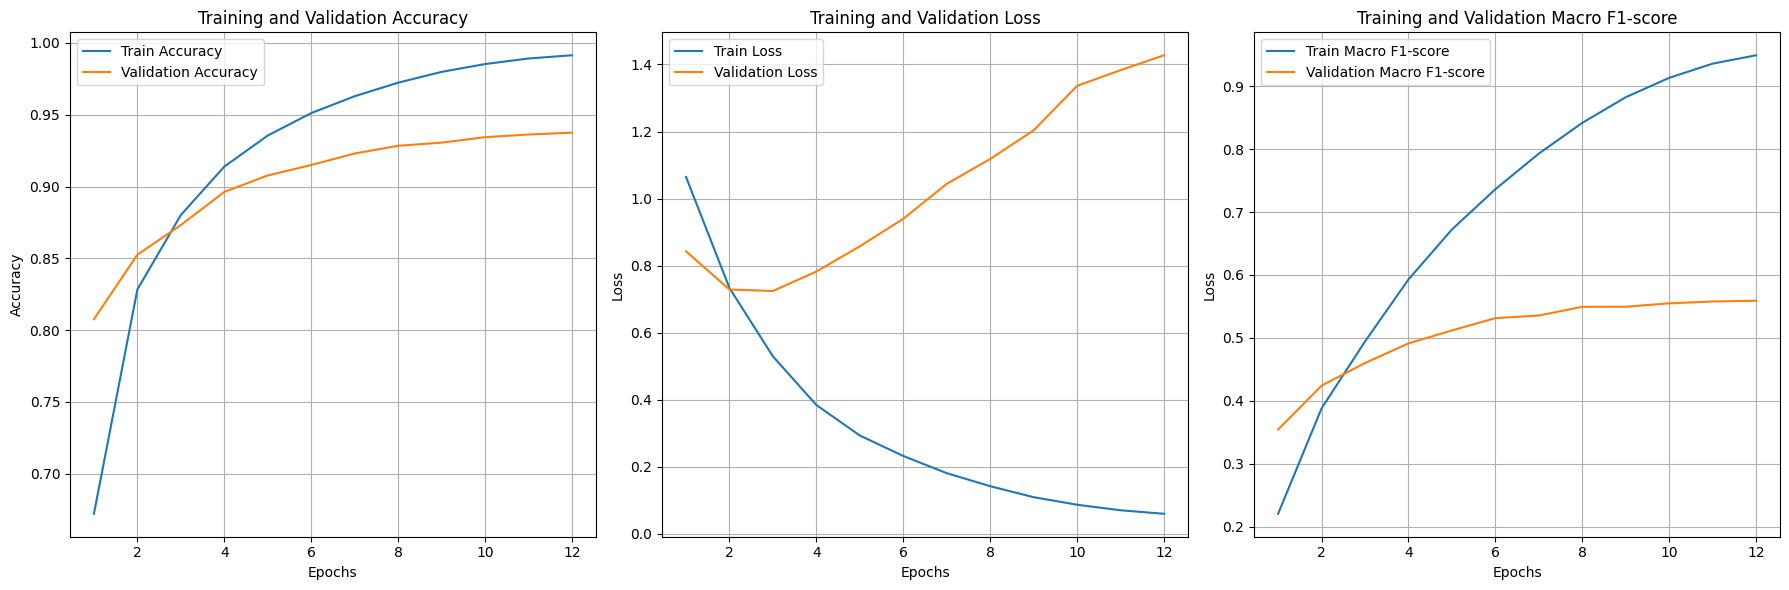

In [42]:
def plot_accu_loss(all_train_accuracies, all_train_losses, all_train_f1, all_val_accuracies, all_val_losses, all_val_f1):
    epochs = range(1, len(all_train_losses) + 1)

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, all_train_accuracies, label='Train Accuracy')
    plt.plot(epochs, all_val_accuracies, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()


    plt.subplot(1, 3, 2)
    plt.plot(epochs, all_train_losses, label='Train Loss')
    plt.plot(epochs, all_val_losses, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()


    plt.subplot(1, 3, 3)
    plt.plot(epochs, all_train_f1, label='Train Macro F1-score')
    plt.plot(epochs, all_val_f1, label='Validation Macro F1-score')
    plt.title('Training and Validation Macro F1-score')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

plot_accu_loss(all_train_accuracies, all_train_losses, all_train_f1, all_val_accuracies, all_val_losses, all_val_f1)

### Evaluation

In [43]:
model = torch.load(f'/kaggle/working/{model_type}bert.pth', weights_only=False)
predict_probs, predicts, real_values = test(model, test_loader, device)

In [44]:
# Generate classification report (macro, micro, and per-label)
print("Classification Report:")
print(classification_report(real_values, predicts, target_names=list(label_dict.values()), zero_division=0))

# Save to excel
report = classification_report(real_values, predicts, target_names=list(label_dict.values()), zero_division=0, output_dict=True)
print(report)
report_df = pd.DataFrame(report).transpose()
report_df.to_excel(f'/kaggle/working/classification_report_{model_type}bert.xlsx', index=True)

Classification Report:
                precision    recall  f1-score   support

     amusement       0.68      0.79      0.73       374
    excitement       0.51      0.43      0.46        98
           joy       0.52      0.59      0.55       204
          love       0.63      0.73      0.68       143
        desire       0.41      0.55      0.47        80
      optimism       0.60      0.65      0.63       142
        caring       0.55      0.68      0.61       150
         pride       0.67      0.64      0.65        86
    admiration       0.52      0.53      0.53       101
     gratitude       0.77      0.86      0.81       108
        relief       0.44      0.60      0.51        60
      approval       0.59      0.68      0.63       115
   realization       0.38      0.39      0.38        95
      surprise       0.49      0.47      0.48        85
     curiosity       0.68      0.69      0.68       100
     confusion       0.41      0.40      0.41        84
          fear       0.6

In [46]:
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay

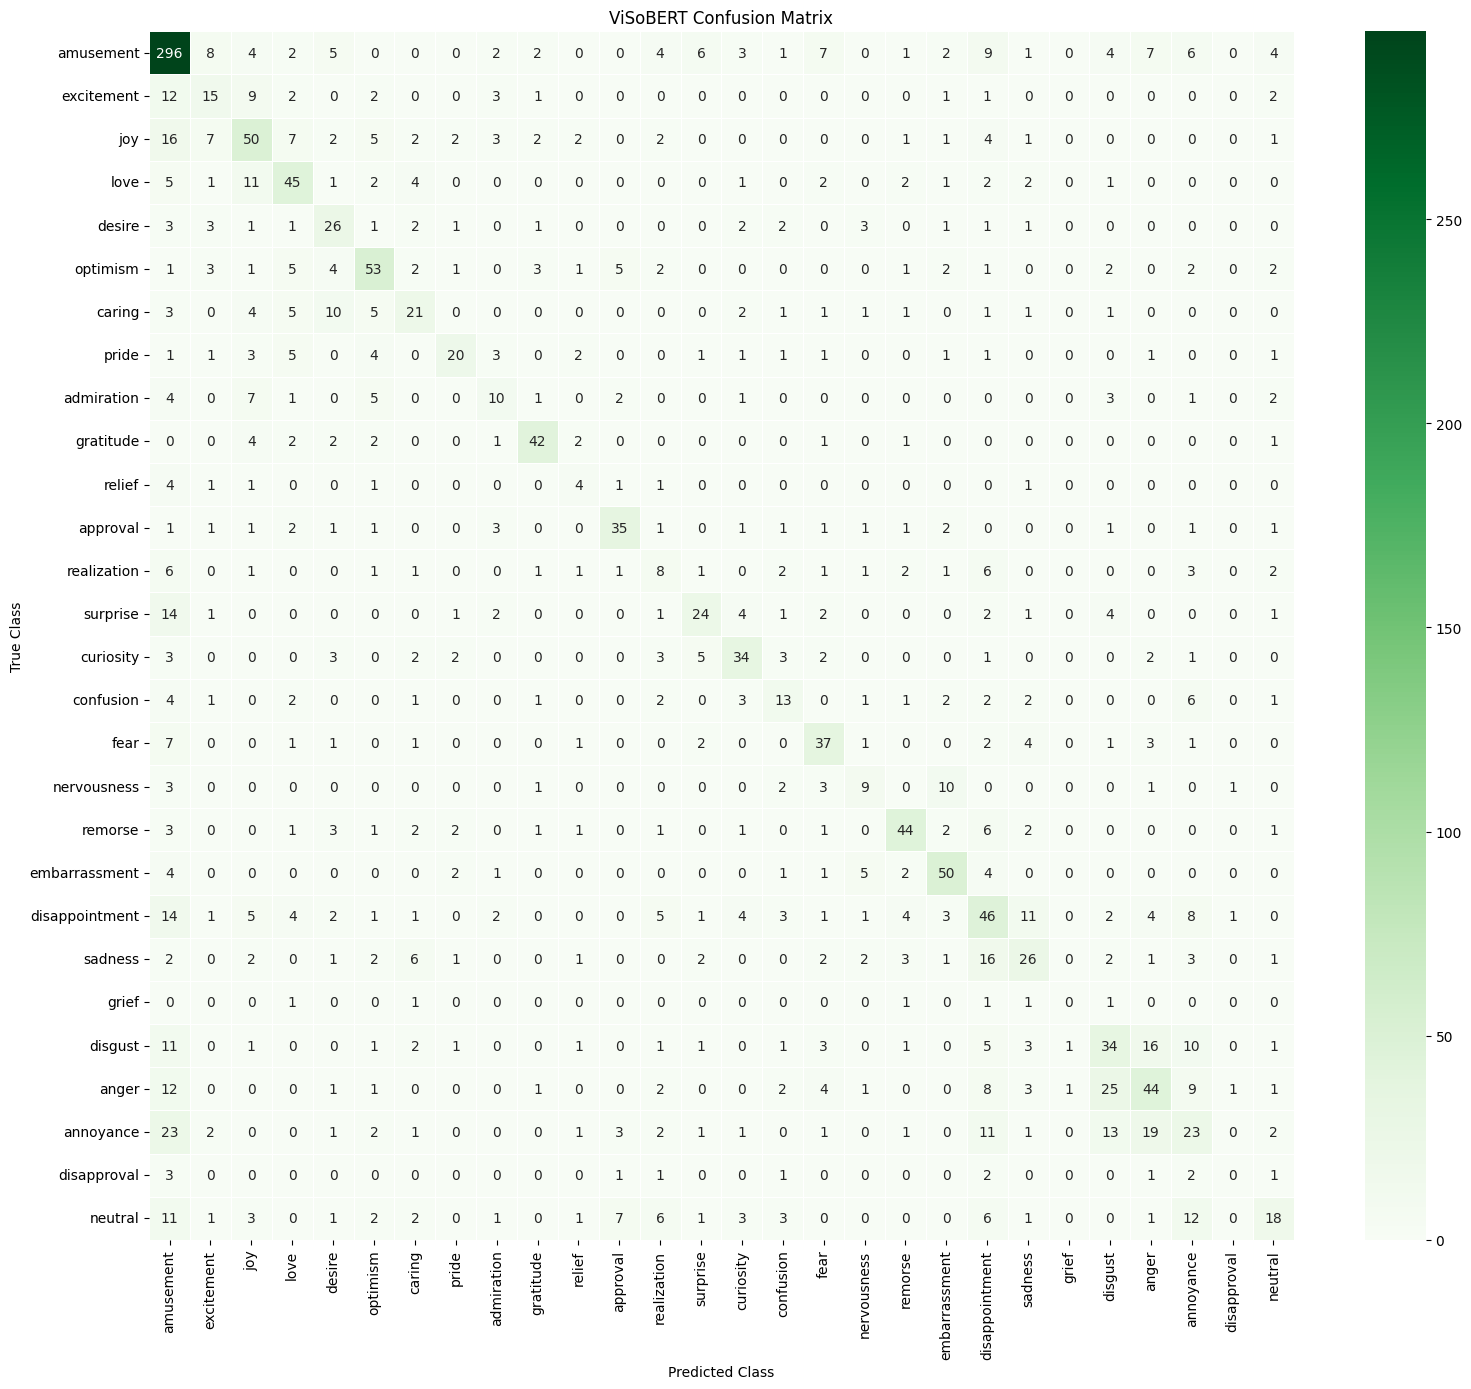

In [49]:
y_true = real_values.numpy() if hasattr(real_values, "numpy") else np.array(real_values)

# y_pred_prob: xác suất dự đoán
# nếu bạn đang có predicts là 0/1 rồi thì dùng predicts
y_pred = predicts.numpy() if hasattr(predicts, "numpy") else np.array(predicts)

class_names = list(label_dict.values())

# Ép multi-label về single-label
true_class = np.argmax(y_true, axis=1)
pred_class = np.argmax(y_pred, axis=1)

# Confusion matrix 28x28
cm = confusion_matrix(true_class, pred_class, labels=list(range(len(class_names))))

plt.figure(figsize=(16, 14))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor="white"
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("ViSoBERT Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("/kaggle/working/visobert_confusion_matrix_28x28.png", dpi=300)
plt.show()

In [45]:
def check_wrong(real_values, predicts):
    wrong_arr = []
    wrong_labels = []
    for i in range(len(predicts)):
        # So sánh element-wise và kiểm tra sự khác biệt
        if not np.array_equal(predicts[i], real_values[i]):
            wrong_arr.append(i)
            wrong_labels.append(predicts[i])  # Lưu toàn bộ vector nhãn dự đoán
    return wrong_arr, wrong_labels

# Gọi hàm check_wrong
wrong_arr, wrong_labels = check_wrong(real_values, predicts)

class_names = list(label_dict.values())

print(f'Wrong predicted using {model_type}bert')
for i in range(10):
    print('-'*50)
    idx = wrong_arr[i]
    wrong_pred = wrong_labels[i]
    real_label = real_values[idx]
    predicted_labels = [class_names[j] for j in range(len(wrong_pred)) if wrong_pred[j] == 1]
    real_labels = [class_names[j] for j in range(len(real_label)) if real_label[j] == 1]

    print(f"Sentence: {test_df.iloc[idx].text}")
    print(f"Predicted: {predicted_labels} --vs-- Real label: {real_labels}")

Wrong predicted using visobert
--------------------------------------------------
Sentence: không coi p1 đi xem p2 thì được không ta mai huệ
Predicted: ['curiosity', 'confusion'] --vs-- Real label: ['curiosity']
--------------------------------------------------
Sentence: lại bộ sách kết nối với cuộc sống . . . !
Predicted: ['disappointment', 'annoyance'] --vs-- Real label: ['disappointment']
--------------------------------------------------
Sentence: có ai ngu như tao không đơn phương con nhỏ cạnh nhà 4 năm mặc dù nó ngồi chung bàn với tao suốt mấy năm cấp 3 : ((
Predicted: ['disappointment', 'sadness'] --vs-- Real label: ['embarrassment', 'disappointment', 'sadness']
--------------------------------------------------
Sentence: về nhan sắc , khó có thể có quy định cụ thể lắm bạn . tiêu chuẩn cái đẹp của 20 năm trước và giờ cũng khác nhau . chỉ cần ưa nhìn trong mắt mình thì có thể được coi là đẹp rồi . kể cả trong cùng 1 thời điểm , nhiều idol đẹp trong mắt người này nhưng trong mắt 